## Cell 1 — Imports + config

In [ ]:
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
import tensorflow as tf

# ----------------------------
# Direcciones
# ----------------------------
MODEL_PATH = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_queenRec1.h5")
WAV_PATH   = Path(r"C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\BeesAnna\sound_files\2022-06-14--11-55-10_1__segment0.wav")

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert WAV_PATH.exists(),   f"WAV not found: {WAV_PATH}"

# ----------------------------
# Parámetros de Preprocesamiento
# ----------------------------
SR = 16000
WINDOW_SEC = 2.0
HOP_SEC = 1.0
SMOOTH_SEC = 60.0

# Parámetros MFCC
N_MFCC = 32
N_FFT = int(0.025 * SR)      # 25 ms -> 400
HOP_LEN = int(0.010 * SR)    # 10 ms -> 160
FMIN, FMAX = 20, SR // 2
ADD_DELTAS = True

# Demo behavior
SIMULATE_REALTIME = True   # True = sleep 1s per hop, False = run fast

# Mapeo de etiquetas
CLASS_NAME = {
    0: "0: reina original / funcional",
    1: "1: no presente",
    2: "2: presente y rechazada",
    3: "3: presente y recién aceptada"
}

print("Config OK.")

Config OK.


## Cell 2 — Load the model

In [2]:
model = tf.keras.models.load_model(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

Loaded model: C:\Users\leona\Documents\Thesis_Project_UACH\Temp\Dataset\features_mfcc_labeled\cnn_mfcc_queenRec1.h5


## Cell 3 — Load WAV and resample to 16 kHz mono

In [ ]:
# Cargar como audio monofónico a la frecuencia de muestreo (SR)
audio, sr = librosa.load(str(WAV_PATH), sr=SR, mono=True)

print("Loaded WAV:", WAV_PATH.name)
print("sr:", sr, "samples:", len(audio), "duration (s):", len(audio)/sr)

c:\Users\leona\.conda\envs\bees_rt\lib\site-packages\librosa\core\intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Loaded WAV: 2022-06-14--11-55-10_1__segment0.wav
sr: 16000 samples: 960000 duration (s): 60.0


## Cell 4 — Feature extraction (MFCC + Δ + ΔΔ) for one window

In [ ]:
def peak_normalize(x, eps=1e-9):
    m = np.max(np.abs(x))
    return x if m < eps else (x / (m + eps))

def extract_mfcc_3ch(window_audio: np.ndarray) -> np.ndarray:
    """
    Input: 1D float array of length WINDOW_SEC*SR
    Output: (3, 32, 201) float32  [channels_first]
    """
    # Ajustar normalización de amplitud al estilo de entrenamiento (aprox.)
    w = peak_normalize(window_audio.astype(np.float32))

    mfcc = librosa.feature.mfcc(
        y=w, sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LEN,
        fmin=FMIN, fmax=FMAX
    )  # (32, T)

    if ADD_DELTAS:
        d1 = librosa.feature.delta(mfcc)
        d2 = librosa.feature.delta(mfcc, order=2)
        feat = np.stack([mfcc, d1, d2], axis=0)  # (3, 32, T)
    else:
        feat = mfcc[np.newaxis, :, :]            # (1, 32, T)

    return feat.astype(np.float32)

## Cell 5 — Streaming inference (WAV “as if live”) + smoothing + logs

In [ ]:
win_len = int(WINDOW_SEC * SR)
hop_len = int(HOP_SEC * SR)
smooth_N = int(SMOOTH_SEC / HOP_SEC)

# Buffer circular para el audio
buf = np.zeros(win_len, dtype=np.float32)
write_idx = 0

# Suavizado mediante suma acumulada (running sum)
prob_hist = deque(maxlen=smooth_N)
prob_sum = np.zeros((4,), dtype=np.float64)  # corriendo suma de probabilidades

times, conf_inst, conf_smooth, pred_inst, pred_smooth = [], [], [], [], []

t0 = time.time()
num_hops = int(np.ceil(len(audio) / hop_len))

print(f"Running {num_hops} hops | window={WINDOW_SEC}s hop={HOP_SEC}s smooth={SMOOTH_SEC}s ({smooth_N} preds)")

pos = 0
for step in range(num_hops):
    # Tomar el siguiente fragmento (chunk) del salto (hop)
    chunk = audio[pos:pos+hop_len]
    pos += hop_len

    # Rellenar (padding) el último fragmento si es necesario
    if len(chunk) < hop_len:
        chunk = np.pad(chunk, (0, hop_len - len(chunk)), mode="constant")
    chunk = chunk.astype(np.float32, copy=False)

    # escribir en el buffer circular
    end = write_idx + hop_len
    if end <= win_len:
        buf[write_idx:end] = chunk
    else:
        n1 = win_len - write_idx
        buf[write_idx:] = chunk[:n1]
        buf[:end - win_len] = chunk[n1:]
    write_idx = (write_idx + hop_len) % win_len

    # leer los últimos 2s en el orden correcto (evitar exceso de roll/copy)
    if write_idx == 0:
        window = buf
    else:
        window = np.concatenate([buf[write_idx:], buf[:write_idx]])

    # extracción de características + inferencia
    feat = extract_mfcc_3ch(window)         # (3,32,201)
    x = feat[np.newaxis, ...]               # (1,3,32,201)

    probs = model.predict(x, verbose=0)[0]       # (4,)
    y_hat = int(np.argmax(probs))
    c_hat = float(np.max(probs))

    # actualizar el suavizado de la media móvil
    if len(prob_hist) == prob_hist.maxlen:
        prob_sum -= prob_hist[0]
    prob_hist.append(probs)
    prob_sum += probs
    probs_s = (prob_sum / len(prob_hist)).astype(np.float32)

    y_s = int(np.argmax(probs_s))
    c_s = float(np.max(probs_s))

    # STATE.update({"t": float(sec), "class": int(y_s), "confidence": float(c_s)})

    sec = step * HOP_SEC
    times.append(sec)
    conf_inst.append(c_hat)
    conf_smooth.append(c_s)
    pred_inst.append(y_hat)
    pred_smooth.append(y_s)

    if step % 5 == 0:  # imprimir cada 5 segundos para reducir spam/sobrecarga
        print(f"t={sec:6.1f}s | inst={CLASS_NAME[y_hat]:28s} conf={c_hat:0.3f} | smooth={CLASS_NAME[y_s]:28s} conf={c_s:0.3f}")

    if SIMULATE_REALTIME:
        elapsed = time.time() - t0
        target = (step + 1) * HOP_SEC
        sleep_time = target - elapsed
        if sleep_time > 0:
            time.sleep(sleep_time)

print("Done.")

Running 60 hops | window=2.0s hop=1.0s smooth=60.0s (60 preds)
t=   0.0s | inst=2: present & rejected        conf=0.512 | smooth=2: present & rejected        conf=0.512
t=   5.0s | inst=3: present & newly accepted  conf=1.000 | smooth=3: present & newly accepted  conf=0.910
t=  10.0s | inst=3: present & newly accepted  conf=1.000 | smooth=3: present & newly accepted  conf=0.951
t=  15.0s | inst=3: present & newly accepted  conf=0.861 | smooth=3: present & newly accepted  conf=0.957
t=  20.0s | inst=3: present & newly accepted  conf=1.000 | smooth=3: present & newly accepted  conf=0.966
t=  25.0s | inst=3: present & newly accepted  conf=1.000 | smooth=3: present & newly accepted  conf=0.973
t=  30.0s | inst=3: present & newly accepted  conf=1.000 | smooth=3: present & newly accepted  conf=0.977
t=  35.0s | inst=3: present & newly accepted  conf=1.000 | smooth=3: present & newly accepted  conf=0.980
t=  40.0s | inst=3: present & newly accepted  conf=1.000 | smooth=3: present & newly acce

## Cell 6 — Plot confidence over time + smoothed class timeline

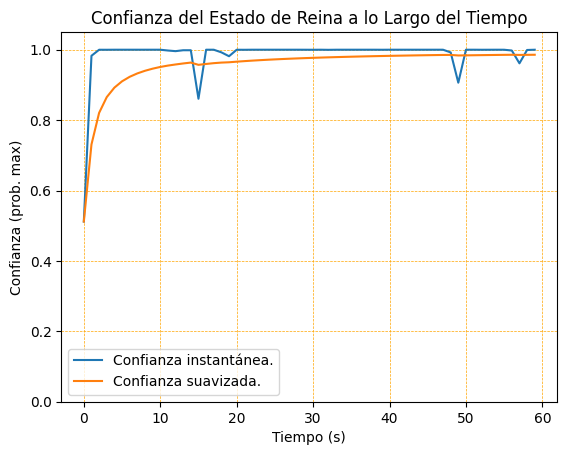

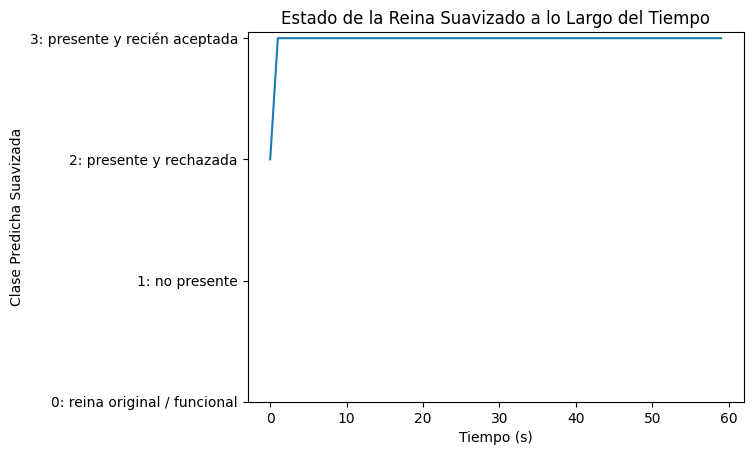

In [8]:
times = np.array(times)
conf_inst = np.array(conf_inst)
conf_smooth = np.array(conf_smooth)
pred_smooth = np.array(pred_smooth)

plt.figure()
plt.plot(times, conf_inst, label="Confianza instantánea.")
plt.plot(times, conf_smooth, label="Confianza suavizada.")
plt.xlabel("Tiempo (s)")
plt.ylabel("Confianza (prob. max)")
plt.ylim(0, 1.05)
plt.grid(color = 'orange', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.title("Confianza del Estado de Reina a lo Largo del Tiempo")
plt.show()

plt.figure()
plt.plot(times, pred_smooth)
plt.yticks([0,1,2,3], [CLASS_NAME[i] for i in [0,1,2,3]])
plt.xlabel("Tiempo (s)")
plt.ylabel("Clase Predicha Suavizada")
plt.title("Estado de la Reina Suavizado a lo Largo del Tiempo")
plt.show()

# Optional: minimal “phone opens browser” interface (JSON endpoint)

This is optional and clean for a thesis pitch: your “device” runs a local server, the phone reads it.

## Cell 7 — Start a tiny local JSON API (Flask)

In [ ]:
# pip install flask  (only if you don't have it)
from flask import Flask, jsonify
import threading

app = Flask(__name__)

# We’ll expose the latest smoothed prediction
STATE = {"t": None, "class": None, "confidence": None}

@app.get("/status")
def status():
    return jsonify(STATE)

def run_server():
    # host="0.0.0.0" makes it reachable from your phone on the same Wi-Fi
    app.run(host="0.0.0.0", port=8000, debug=False, use_reloader=False)

# Start server in background thread
threading.Thread(target=run_server, daemon=True).start()
print("Server running. Open http://<your-laptop-ip>:8000/status on your phone (same Wi-Fi).")

Server running. Open http://<your-laptop-ip>:8000/status on your phone (same Wi-Fi).
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8000
 * Running on http://192.168.0.20:8000
INFO:werkzeug:Press CTRL+C to quit


Then, inside your streaming loop (Cell 5), add/update this line after computing ```y_s, c_s```:

In [ ]:
STATE.update({"t": float(sec), "class": int(y_s), "confidence": float(c_s)})

INFO:werkzeug:192.168.0.13 - - [14/Feb/2026 13:43:53] "GET /status HTTP/1.1" 200 -
INFO:werkzeug:192.168.0.13 - - [14/Feb/2026 13:44:04] "GET /status HTTP/1.1" 200 -
INFO:werkzeug:192.168.0.13 - - [14/Feb/2026 13:44:17] "GET /status HTTP/1.1" 200 -
INFO:werkzeug:192.168.0.13 - - [14/Feb/2026 13:45:10] "GET /status HTTP/1.1" 200 -


That’s it: phone sees live JSON.